In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.1 MB/s eta 0:00:00


In [ ]:
## Choose model type between V1 and V5

modelType = "V5"

In [ ]:
repoPath = ""

if (modelType in ["V4", "V5"]): ## New version of the database
  !rm -rf ProjetApprentissageProfond_DB
  !git clone https://github.com/Frenox/ProjetApprentissageProfond_DB
  repoPath = "/content/ProjetApprentissageProfond_DB/Repartition"
else: ## Old version of the database
  REPO_URL="https://github.com/Frenox/ProjetApprentissageProfond_DB"
  COMMIT_HASH="6fb92025e3518addf3b7e6d484bb976504eb02b4"

  !rm -rf ProjetApprentissageProfond_DB_OLD
  !git clone $REPO_URL ProjetApprentissageProfond_DB_OLD
  %cd ProjetApprentissageProfond_DB_OLD

  # Ensure we have full history in case of shallow issues
  !git fetch --all

  !git checkout $COMMIT_HASH
  repoPath = "/content/ProjetApprentissageProfond_DB_OLD/Repartition"

Cloning into 'ProjetApprentissageProfond_DB'...
remote: Enumerating objects: 961, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 961 (delta 47), reused 55 (delta 23), pack-reused 830 (from 1)
Receiving objects: 100% (961/961), 153.29 MiB | 17.46 MiB/s, done.
Resolving deltas: 100% (135/135), done.


In [ ]:
yaml_text = f"""
path: {repoPath}

train: train/images
val: check/images
test: test/images

names:
  0: Violon
  1: Violoncelle
  2: Alto
  3: Contrebasse
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_text)

In [ ]:
from ultralytics import YOLO

match modelType:
        case "V1":
          model = YOLO("yolov8n.pt")
          model.train(
            data="/content/data.yaml",
            epochs=50,
            imgsz=640,
            batch=16
          )
        case "V2":
          model = YOLO("yolov8s.pt")
          model.train(
            data="/content/data.yaml",
            epochs=100,
            imgsz=960,
            batch=16
          )
        case "V3":
          model = YOLO("yolov8s.pt")
          model.train(
            data="/content/data.yaml",
            epochs=100,
            imgsz=960,
            batch=16,

            ## Augmentation
            mosaic=1.0,        # strong mix of images
            fliplr=0.5,        # horizontal flip probability
            degrees=5.0,       # small rotations
            translate=0.1,     # shifting
            scale=0.5,          # zoom in/out

            close_mosaic=15
          )
        case "V4":
          model = YOLO("yolov8s.pt")
          model.train(
            data="/content/data.yaml",
            epochs=100,
            imgsz=960,
            batch=16,

            ## Augmentation
            mosaic=1.0,        # strong mix of images
            fliplr=0.5,        # horizontal flip probability
            degrees=5.0,       # small rotations
            translate=0.1,     # shifting
            scale=0.5,          # zoom in/out

            close_mosaic=15
          )
        case "V5":
          model = YOLO("yolov8s.pt")
          model.train(
            data="/content/data.yaml",
            epochs=150,
            imgsz=960,
            batch=16,

            ## Augmentation
            mosaic=1.0,        # strong mix of images
            fliplr=0.5,        # horizontal flip probability
            degrees=5.0,       # small rotations
            translate=0.1,     # shifting
            scale=0.5,          # zoom in/out

            close_mosaic=15
          )
        case _:
            pass

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, 

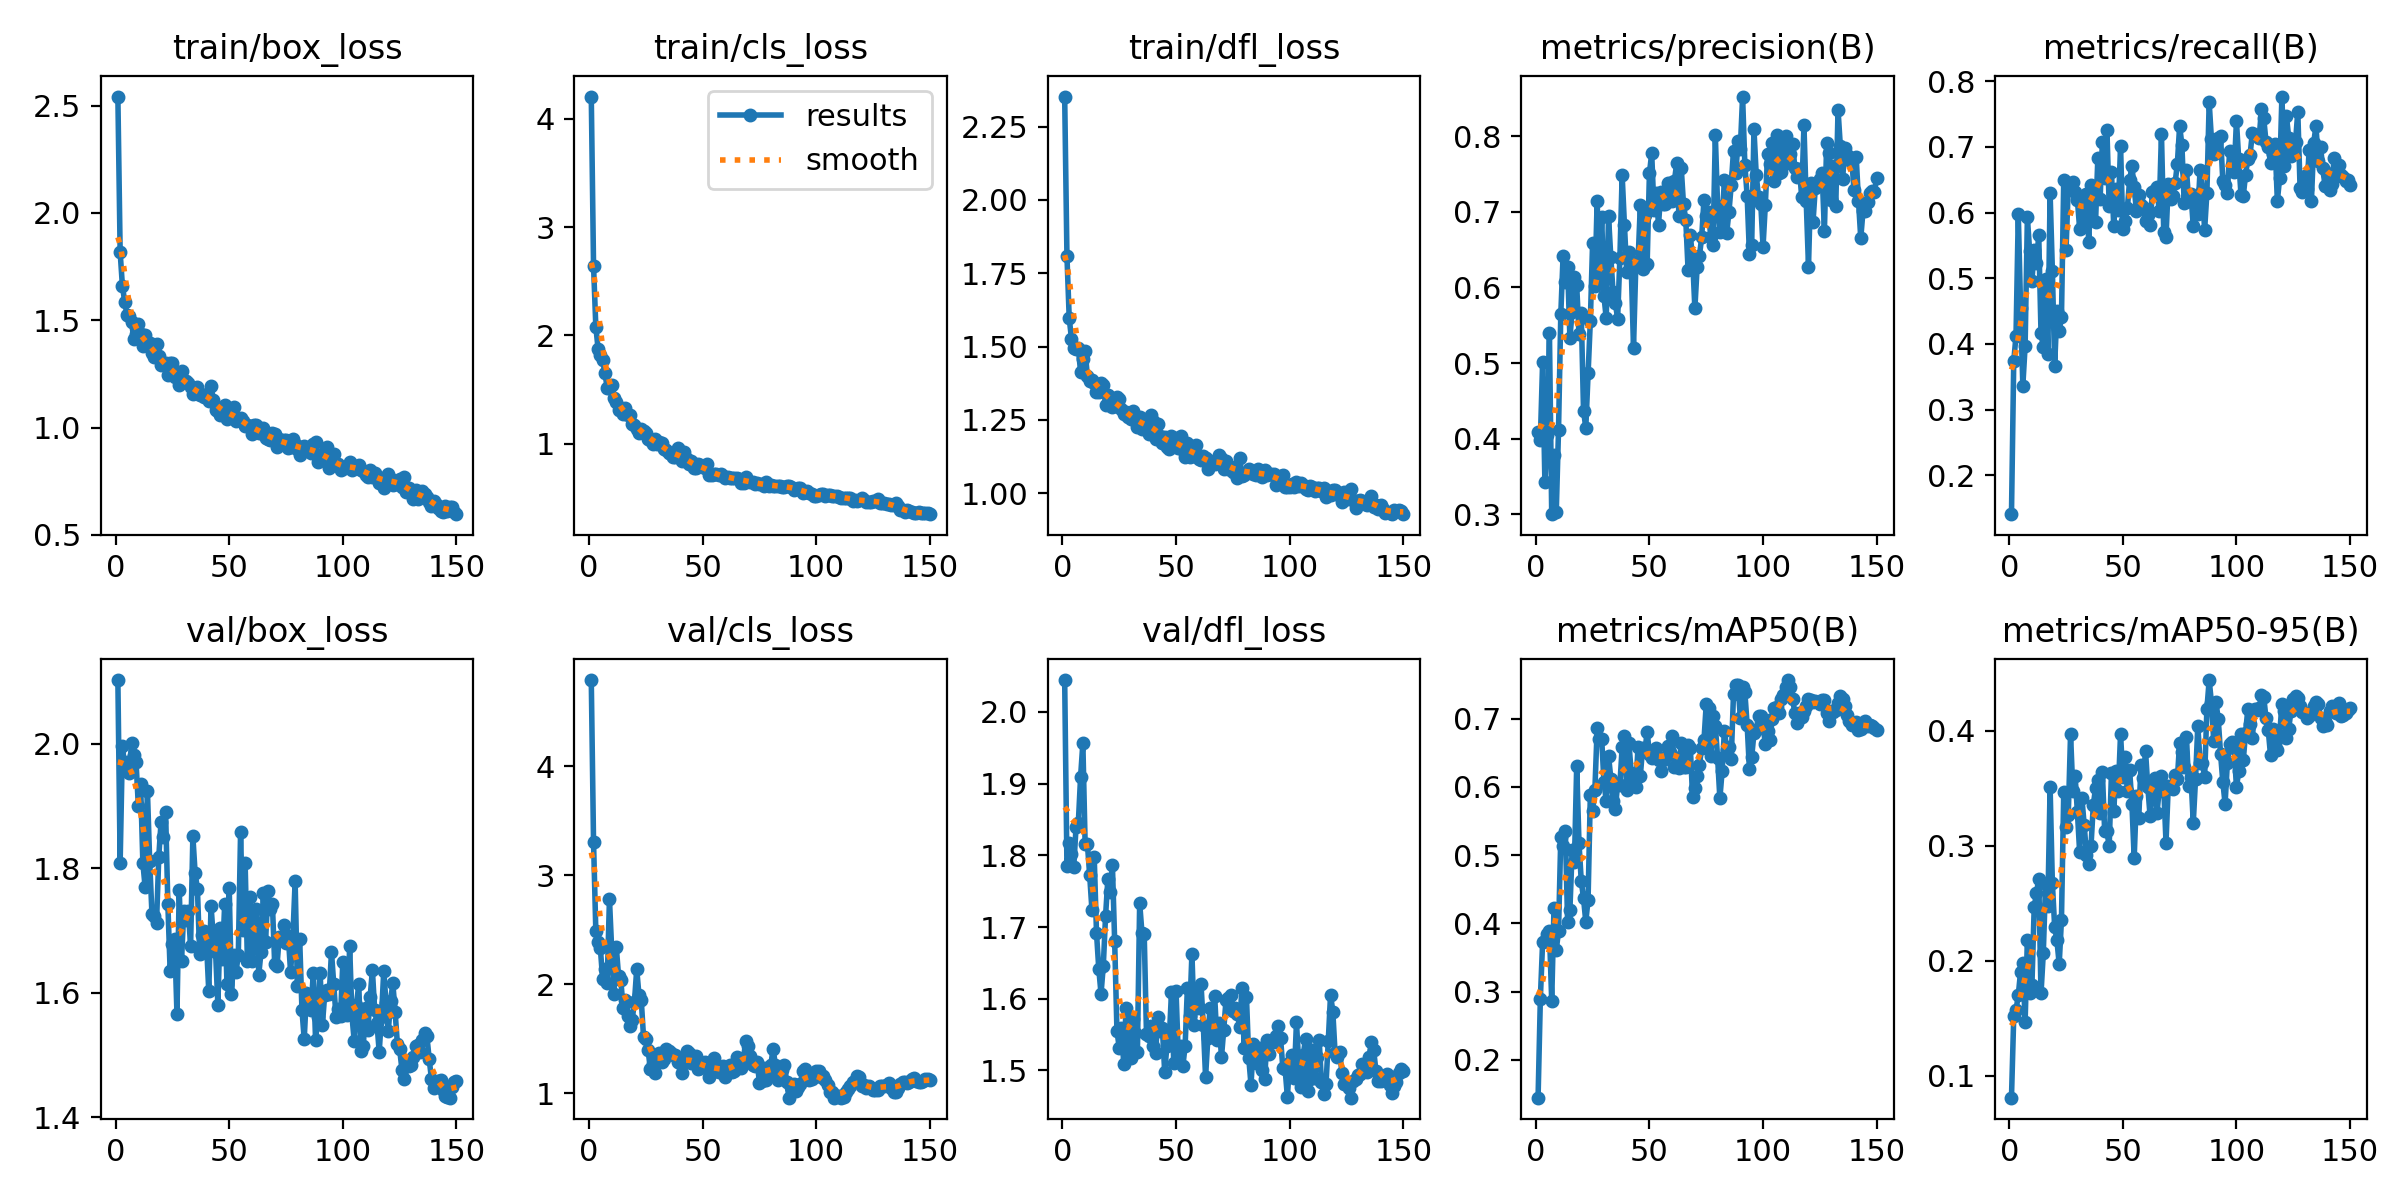

In [ ]:
from IPython.display import Image

Image(filename="runs/detect/train/results.png")

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/content/data.yaml",
    split="test",
    plots=True,
    iou=0.5,
    agnostic_nms=True
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2830.2±1505.4 MB/s, size: 368.3 KB)
val: Scanning /content/ProjetApprentissageProfond_DB/Repartition/test/labels.cache... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 8.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 2.0s
                   all         25        121      0.768      0.633      0.618      0.371
                Violon         18         57       0.77      0.647      0.666      0.413
           Violoncelle         12         24      0.831      0.625      0.587      0.383
                  Alto         10         19      0.603      0.632      0.544      0.322
           Contrebasse          5         21      0.868      0.626      0.677      0.366
Speed: 10.9ms prep

In [ ]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

precision = metrics.box.mp
recall = metrics.box.mr

f1 = 2 * precision * recall / (precision + recall + 1e-16)
print("F1-score:", f1)

# Valeurs V5 :
# Precision: 0.7679758468984181
# Recall: 0.6325256244585735
# mAP50: 0.6184806749469884
# mAP50-95: 0.3711806647422715
# F1-score: 0.6937006666017291

Precision: 0.7679758468984181
Recall: 0.6325256244585735
mAP50: 0.6184806749469884
mAP50-95: 0.3711806647422715
F1-score: 0.6937006666017291


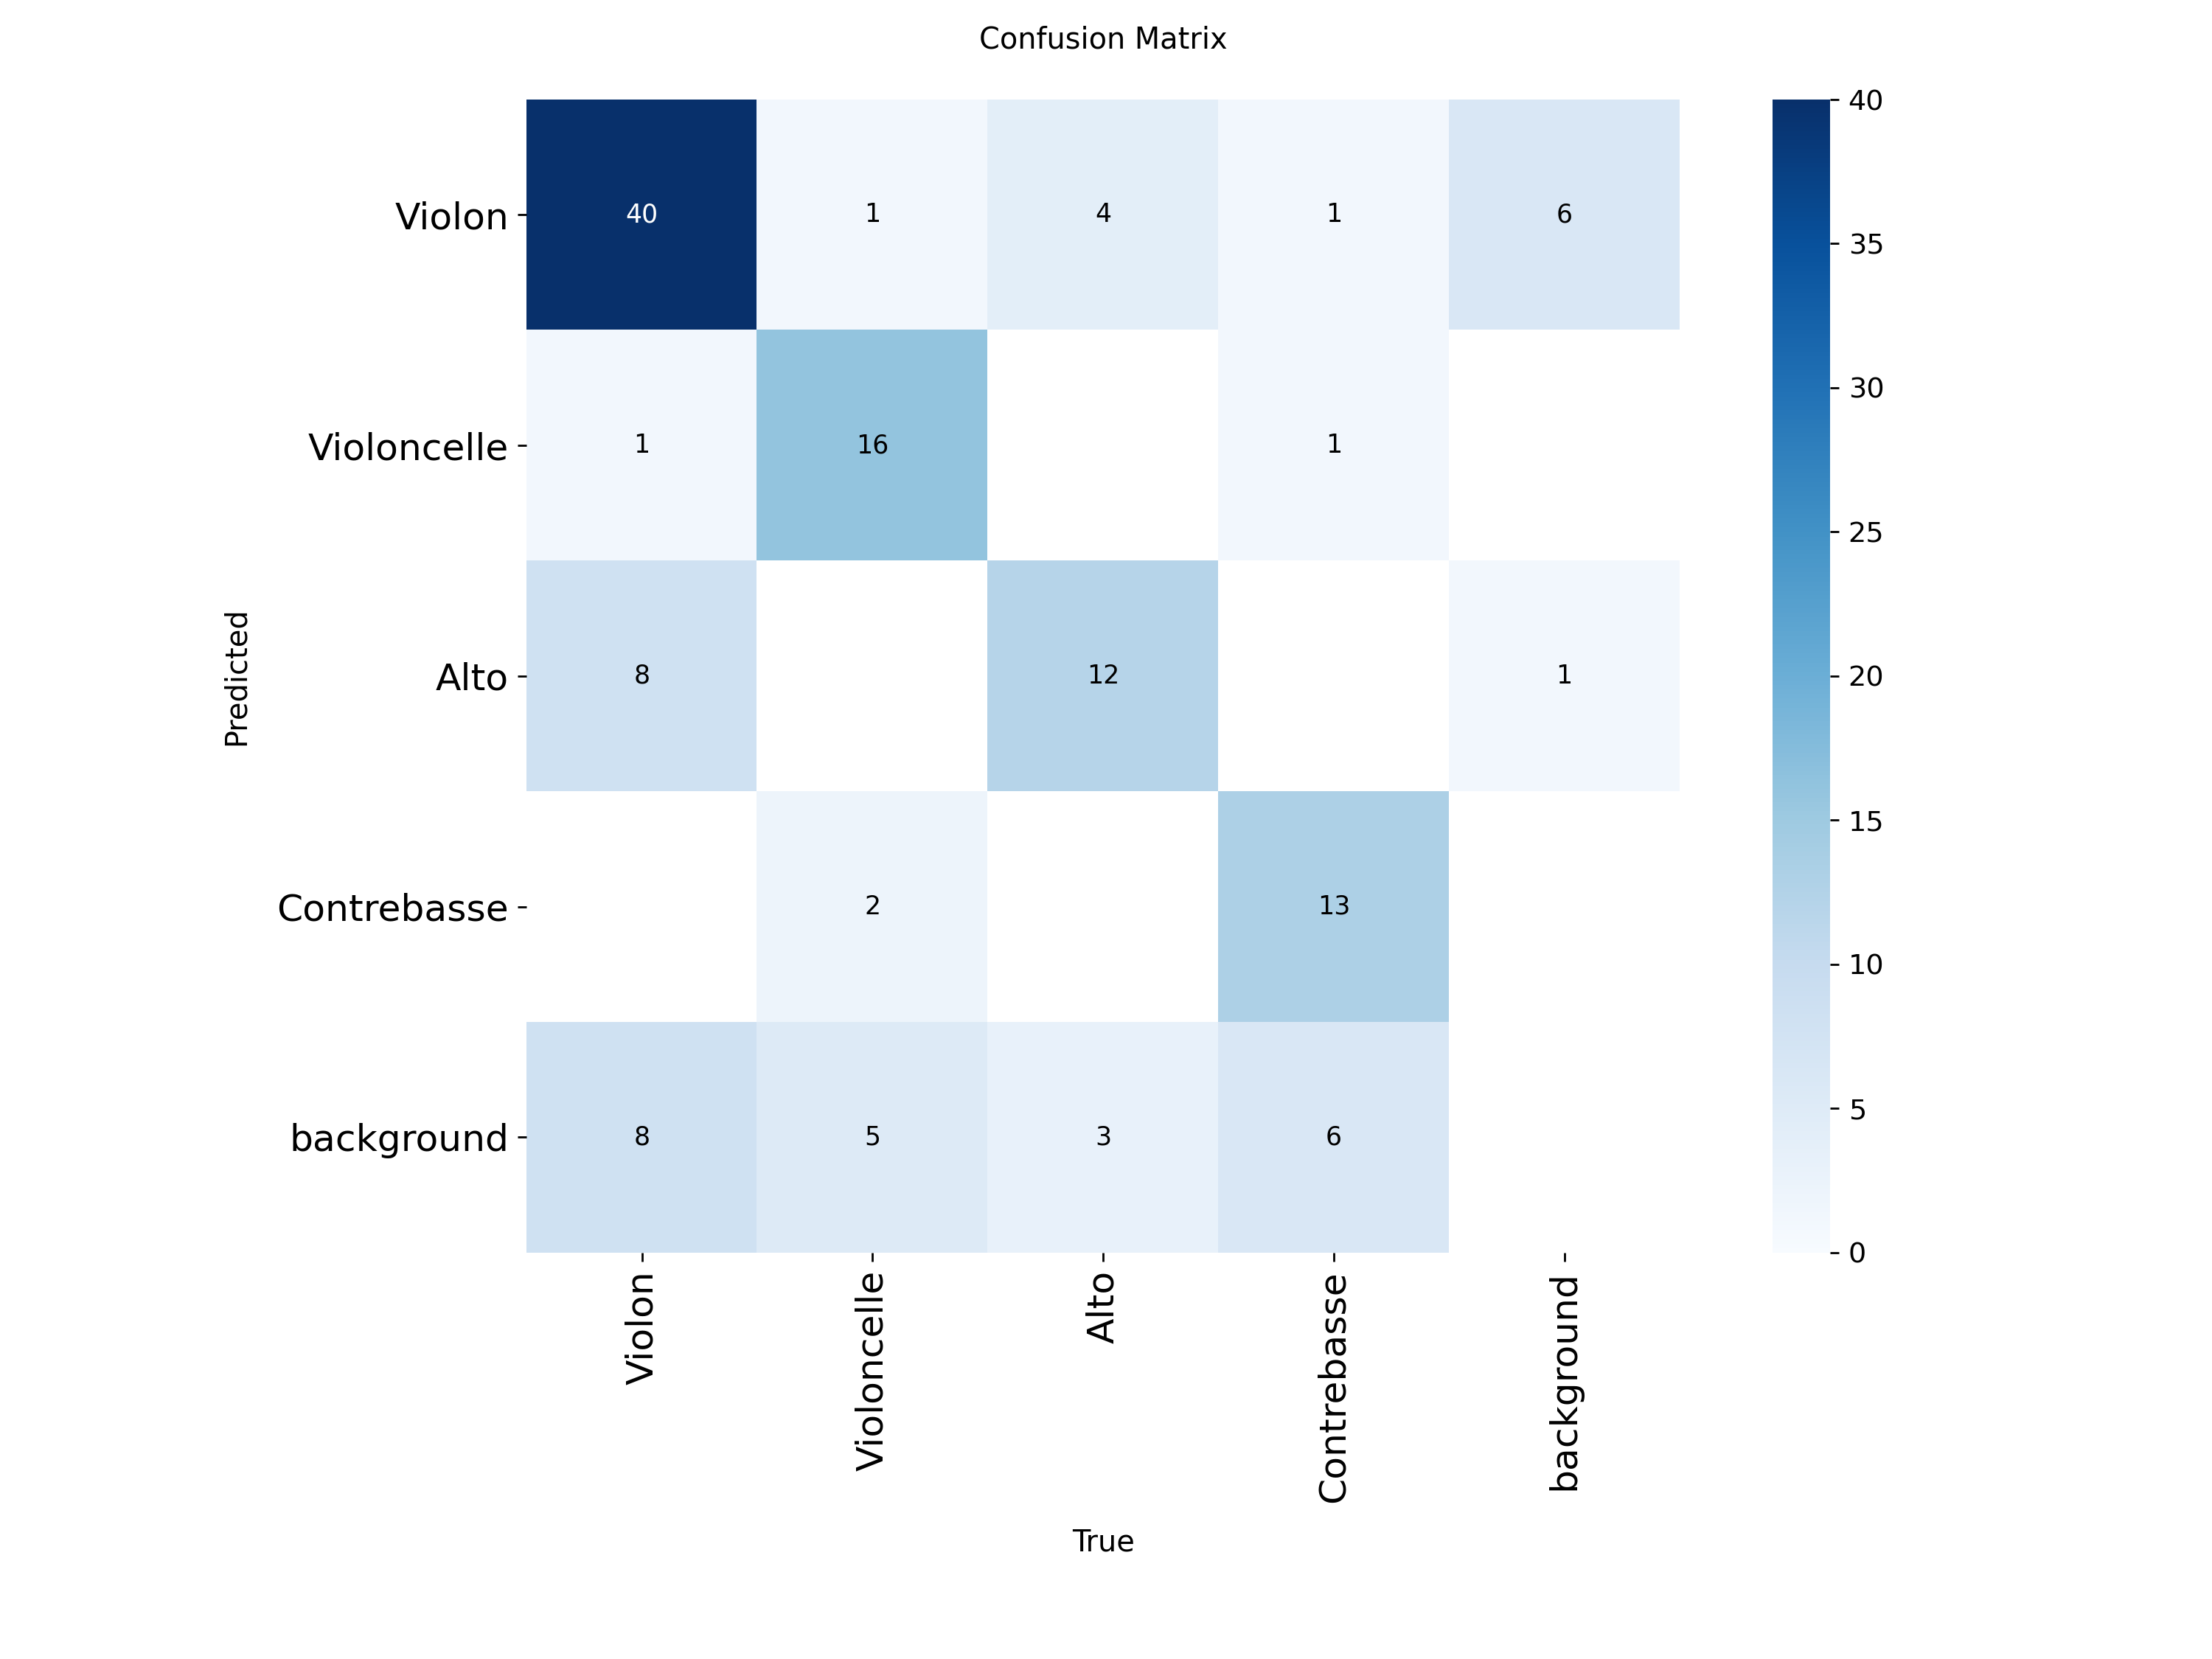

In [ ]:
from IPython.display import Image

Image("runs/detect/val/confusion_matrix.png")


image 1/1 /content/ProjetApprentissageProfond_DB/Repartition/train/images/images_orchestre_faible_qualite.jpg: 640x960 9 Violons, 4 Violoncelles, 3 Altos, 1 Contrebasse, 80.7ms
Speed: 5.5ms preprocess, 80.7ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 960)


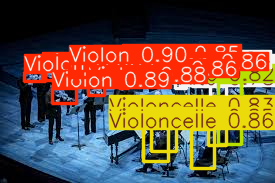

In [ ]:
## Affichage test

import glob, random

img = random.choice(glob.glob(f"{repoPath}/train/images/*.jpg"))

results = model.predict(
    source=img,
    conf=0.25,
    iou=0.5
)

for r in results:
    annotated = r.plot()

from IPython.display import display
from PIL import Image as PILImage

display(PILImage.fromarray(annotated))


image 1/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/Eloi18.png: 480x960 2 Violoncelles, 3 Altos, 2 Contrebasses, 81.8ms
image 2/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/Eloi2.png: 416x960 1 Violon, 81.8ms
image 3/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/Eloi23.png: 576x960 2 Violons, 1 Alto, 80.0ms
image 4/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/Eloi24.png: 288x960 2 Violons, 7 Altos, 80.4ms
image 5/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/Eloi3.png: 576x960 1 Violon, 21.1ms
image 6/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/Eloi4.png: 384x960 1 Violon, 1 Violoncelle, 4 Altos, 90.9ms
image 7/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/IMG0.jpg: 544x960 4 Violons, 86.9ms
image 8/25 /content/ProjetApprentissageProfond_DB/Repartition/test/images/IMG_0519.jpg: 640x960 13 Violons, 1 Alto, 21.6ms
image 9/25 /content/ProjetApp

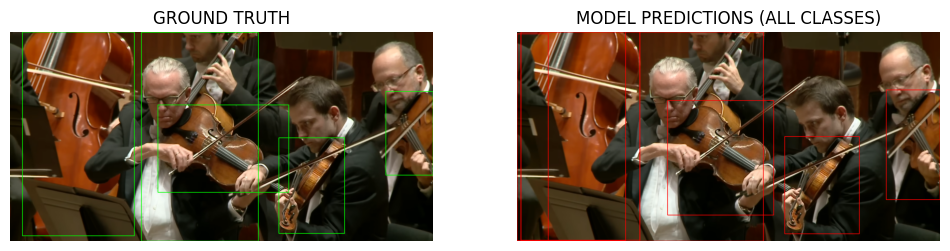

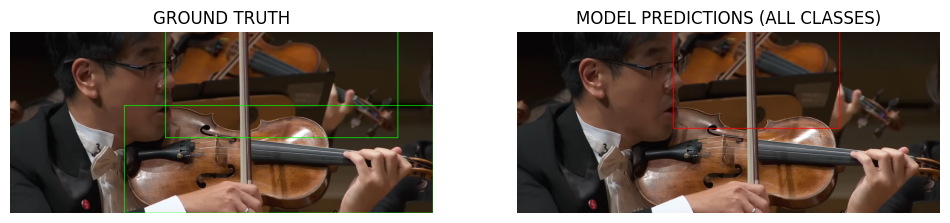

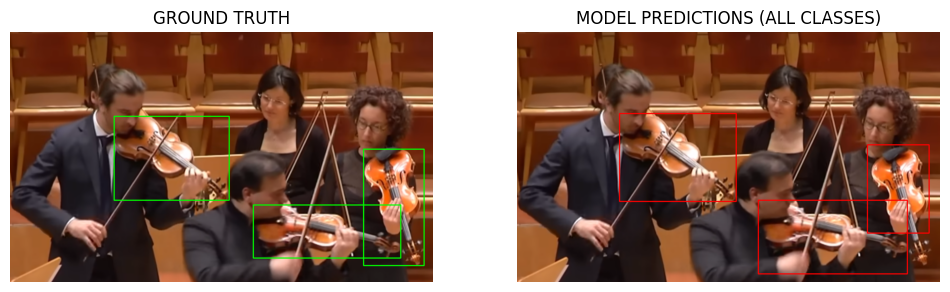

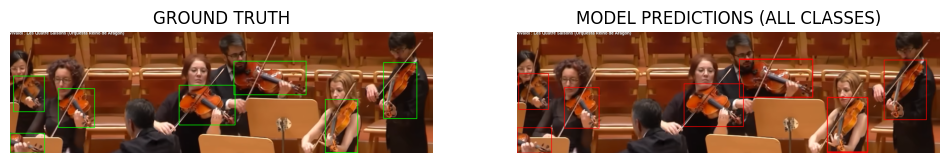

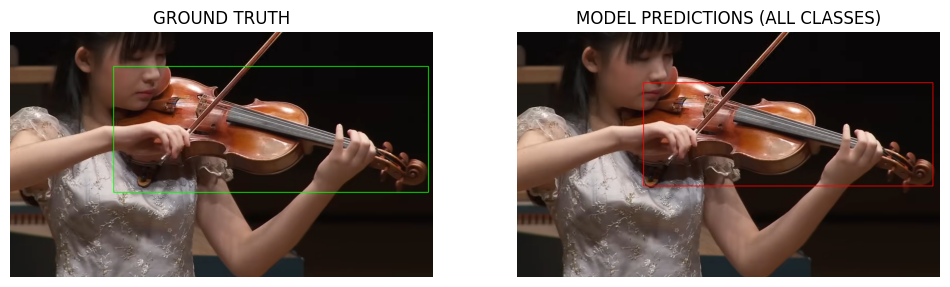

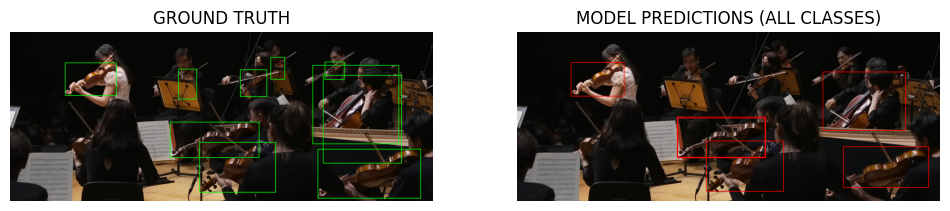

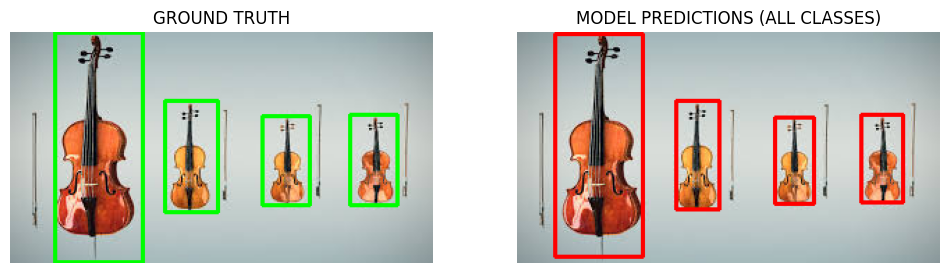

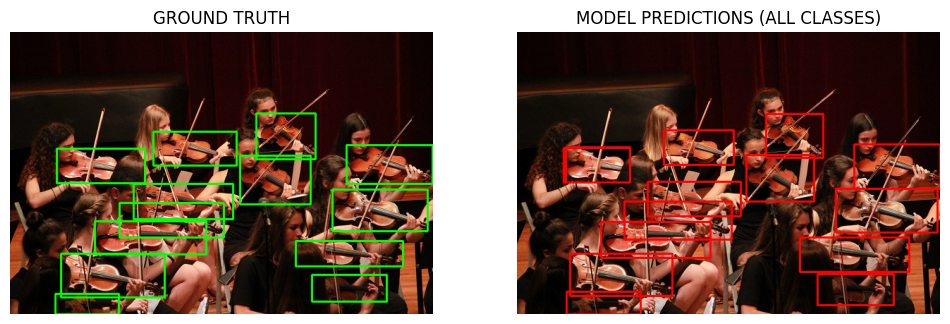

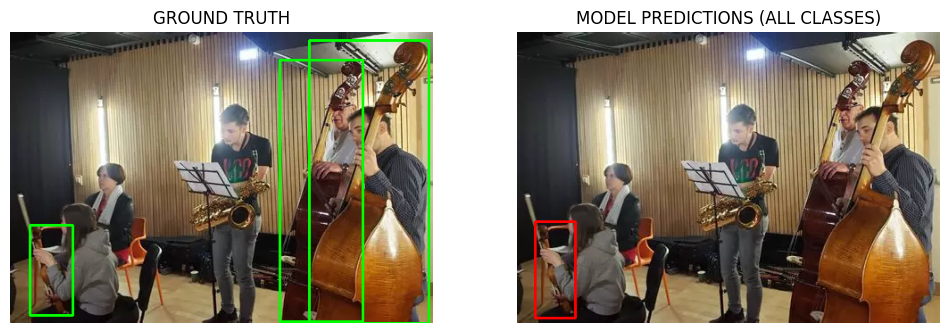

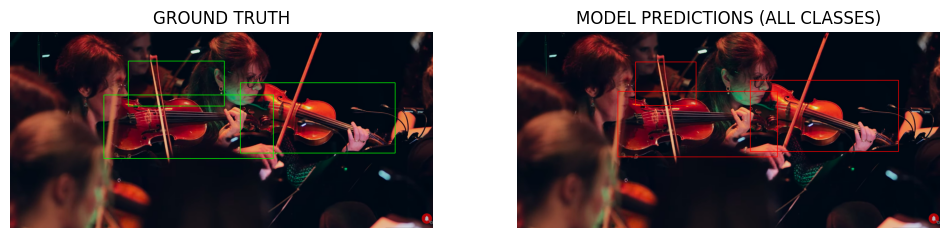

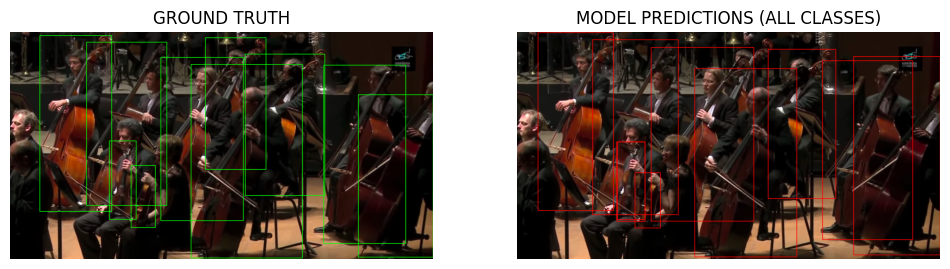

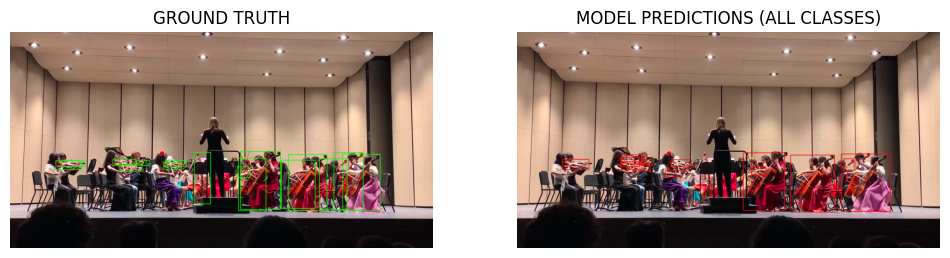

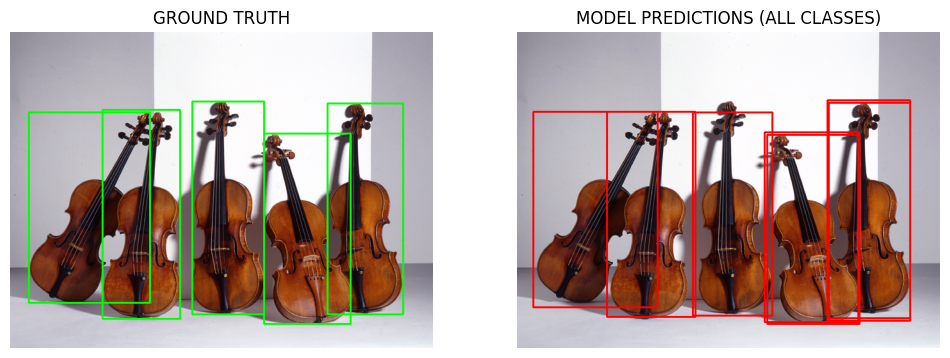

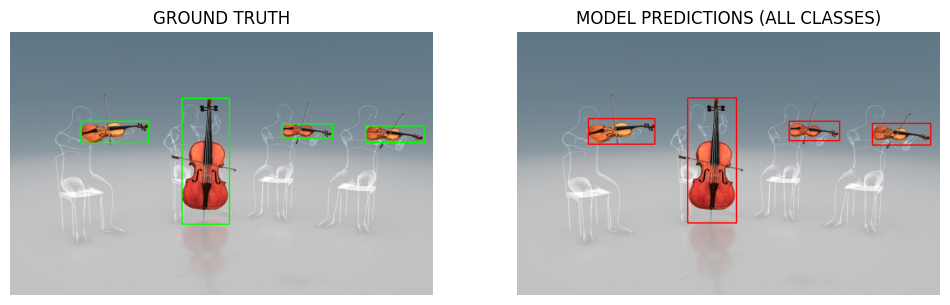

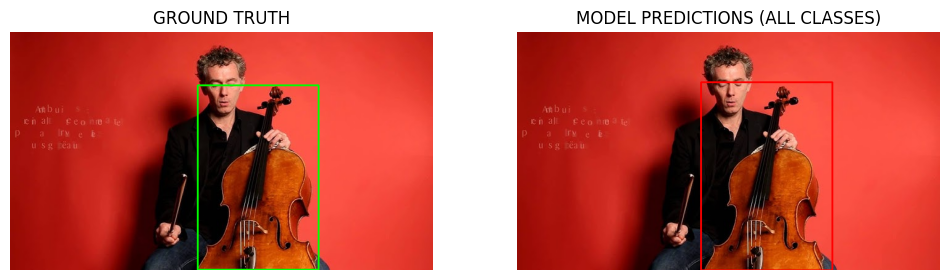

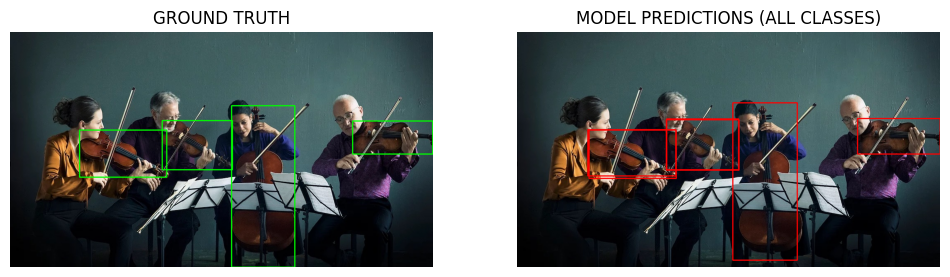

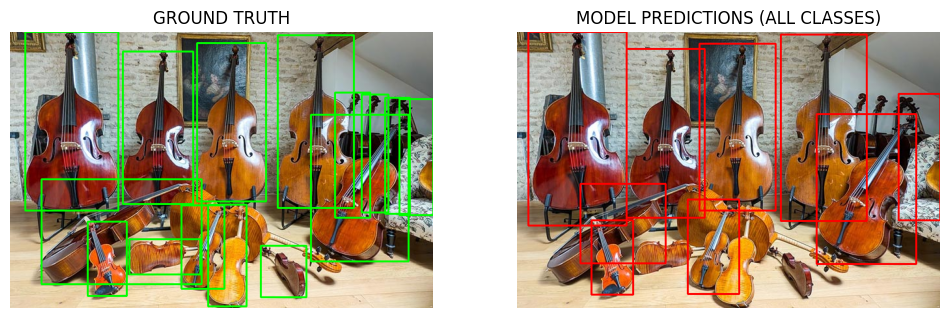

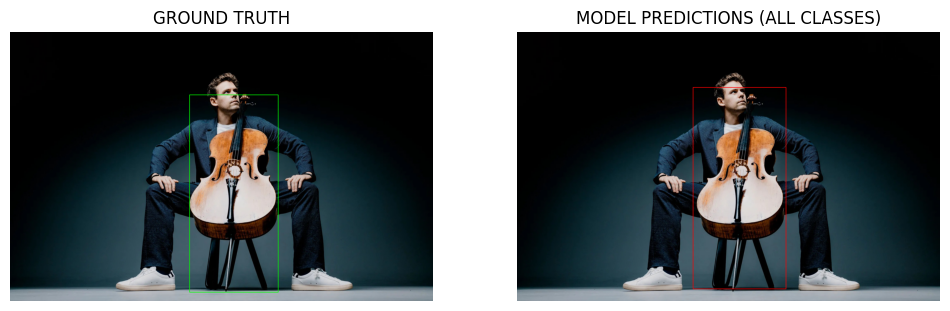

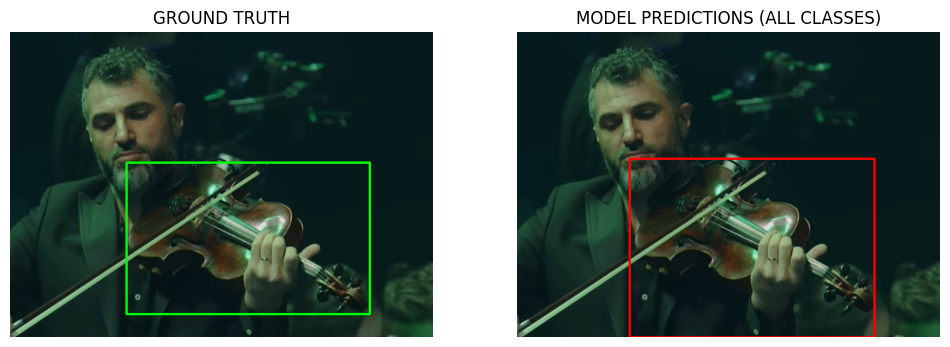

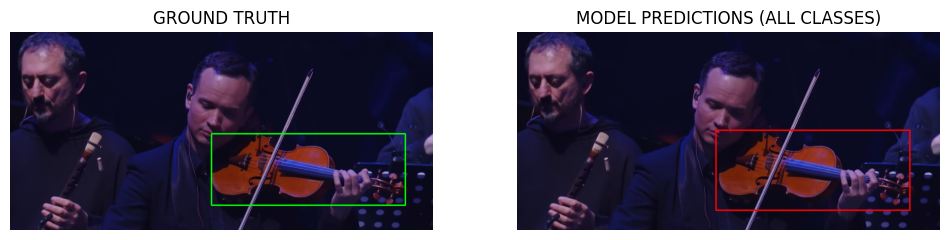

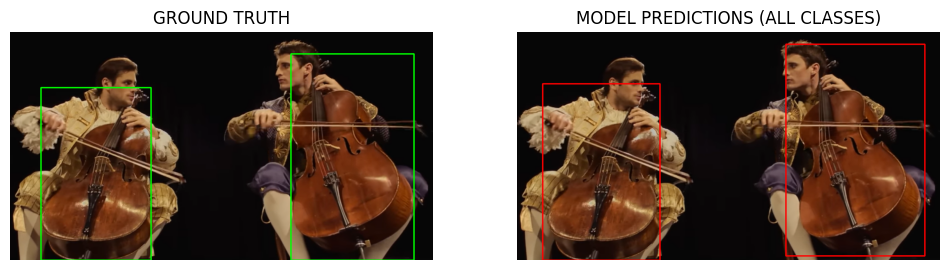

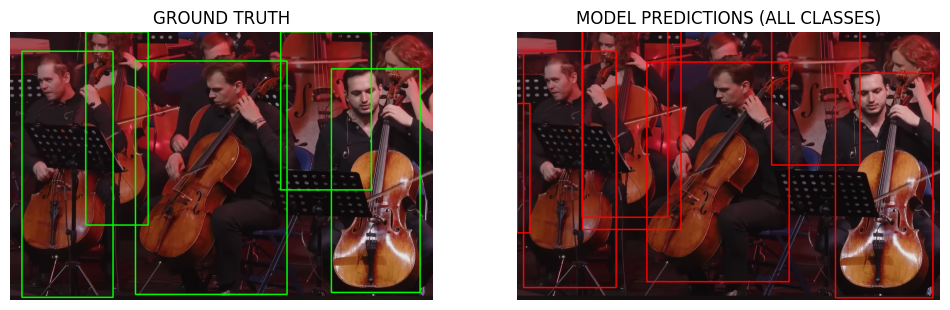

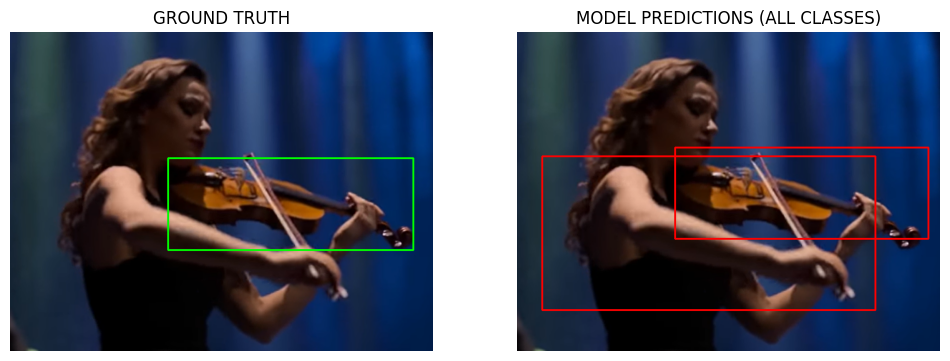

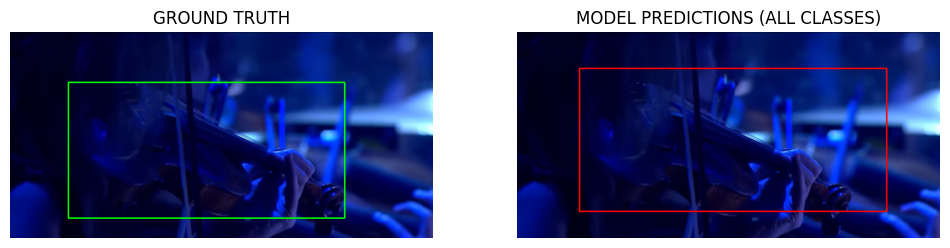

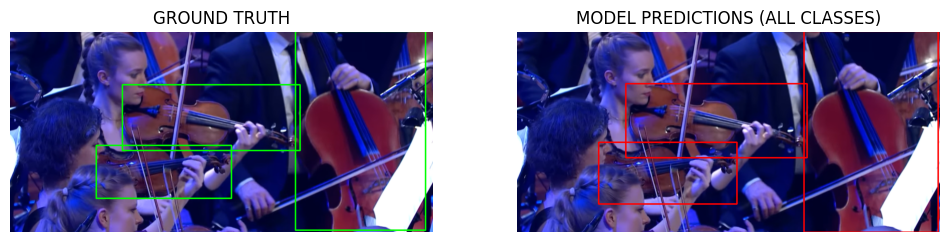

In [ ]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt

# CONFIG
images_path = f"{repoPath}/test/images"
labels_path = f"{repoPath}/test/labels"


def load_labels(label_file):
    if not os.path.exists(label_file):
        return []
    with open(label_file, "r") as f:
        return [line.strip().split() for line in f.readlines()]


def yolo_to_xyxy(label, img_w, img_h):
    _, xc, yc, w, h = label
    xc, yc, w, h = map(float, (xc, yc, w, h))

    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h

    return [x1, y1, x2, y2]


results = model.predict(source=images_path, conf=0.25, iou=0.5, save=False)


for r in results:

    img_path = r.path
    filename = os.path.basename(img_path)
    label_file = os.path.join(labels_path, os.path.splitext(filename)[0] + ".txt")

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w = img.shape[:2]

    # ---------------- GT ----------------
    gt_img = img.copy()
    gt_labels = load_labels(label_file)

    for l in gt_labels:
        x1, y1, x2, y2 = map(int, yolo_to_xyxy(l, w, h))
        cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # ---------------- FULL MODEL PREDICTIONS ----------------
    pred_img = img.copy()

    if r.boxes is not None:
        for box in r.boxes.xyxy.cpu().numpy():
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(pred_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # ---------------- DISPLAY ----------------
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("GROUND TRUTH")
    plt.imshow(gt_img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("MODEL PREDICTIONS (ALL CLASSES)")
    plt.imshow(pred_img)
    plt.axis("off")

    plt.show()